# Deep Learning Project: Energy Output Prediction(ANN)
## Dataset : Power Plant 


## Importing libraries and dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
df.shape

(9568, 5)

In [5]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [6]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [7]:
x = df.drop(columns = "PE", axis = 1)
y = df["PE"]

In [8]:
y

0       480.48
1       445.75
2       438.76
3       453.09
4       464.43
         ...  
9563    462.59
9564    432.90
9565    465.96
9566    450.93
9567    451.67
Name: PE, Length: 9568, dtype: float64

## Train-test-spliting

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [10]:
x_train.shape

(7654, 4)

In [11]:
y_train.shape

(7654,)

## Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# converting to tensor

In [13]:
import torch
import torch.nn as nn

x_train_tensor = torch.tensor(x_train_scaled, dtype = torch.float32)
x_test_tensor = torch.tensor(x_test_scaled, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [14]:
x_test_tensor.size(0)


1914

# Tensor dataset and dataloader

In [15]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset = TensorDataset( x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)
train_loader= DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True)

# Define the model

In [16]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
            nn.Linear(6,6),
            nn.ReLU(),
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)



In [17]:
import torch.optim as optim
model = ANN()
crietrion = nn.MSELoss()
optimizer  =  optim.Adam(model.parameters())

# Training Model

In [18]:
train_losses =[]
val_losses= []
best_val_loss = float("inf")
epochs = 60

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for  xb, yb in train_loader:
        optimizer.zero_grad()
        
        outputs = model(xb)
        loss = crietrion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss =crietrion(outputs, yb)
            running_val_loss +=loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
        
    
    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        

epoch 1/60 ==> train loss = 205630.79322916668 & val loss = 203129.57838541668
epoch 2/60 ==> train loss = 194991.9041015625 & val loss = 182353.87682291667
epoch 3/60 ==> train loss = 161262.69052734374 & val loss = 136938.45794270834
epoch 4/60 ==> train loss = 109352.24895833334 & val loss = 83230.53606770834
epoch 5/60 ==> train loss = 62531.30413411458 & val loss = 46256.04886067708
epoch 6/60 ==> train loss = 35981.27744954427 & val loss = 28871.594791666666
epoch 7/60 ==> train loss = 24216.227587890626 & val loss = 20806.039990234374
epoch 8/60 ==> train loss = 18365.837023925782 & val loss = 16327.982047526042
epoch 9/60 ==> train loss = 14596.765344238282 & val loss = 12903.143212890625
epoch 10/60 ==> train loss = 11486.64442545573 & val loss = 9825.820760091146
epoch 11/60 ==> train loss = 8507.444400024415 & val loss = 7045.6855875651045
epoch 12/60 ==> train loss = 5941.719614664714 & val loss = 4765.791670735677
epoch 13/60 ==> train loss = 3937.2501622517902 & val loss 

## Training vs Validation loss(Visualisation)

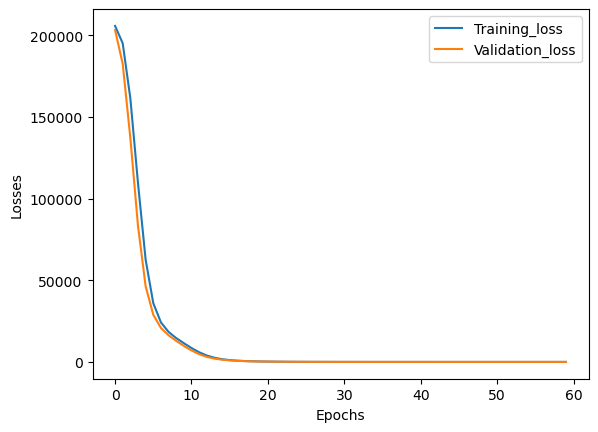

In [19]:
import matplotlib.pyplot as plt
df_loss = pd.DataFrame({'Total_loss': train_losses, 'Val_loss': val_losses})

plt.plot(df_loss["Total_loss"], label = "Training_loss")
plt.plot(df_loss["Val_loss"], label = "Validation_loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

## Loading best model

In [20]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

# Model Evaluation

In [21]:
model.eval()
with torch.no_grad():
    train_pred = model(x_train_tensor)
    test_pred = model(x_test_tensor)

    train_mse_loss = crietrion(train_pred, y_train_tensor)
    test_mse_loss = crietrion(test_pred, y_test_tensor)

    print("Training MSE: ", train_mse_loss)
    print("Testing MSE: ", test_mse_loss)


Training MSE:  tensor(21.6430)
Testing MSE:  tensor(19.9893)


In [22]:
from sklearn.metrics import r2_score
print("r2 Score: ", r2_score(test_pred, y_test_tensor))

r2 Score:  0.9259930849075317


In [23]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns = ["Predicted Values"] )
actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"] )

diff_df = pd.concat([predicted_df, actual_df], axis = 1)

diff_df["Differences"] = diff_df["Actual Values"] - diff_df["Predicted Values"]



In [24]:
diff_df.describe() 

,Predicted Values,Actual Values,Differences
count,1914.000000,1914.000000,1914.000000
mean,453.915314,454.213506,0.298188
std,16.439018,16.920216,4.462147
min,421.168488,425.160000,-27.771165
25%,440.097931,439.845000,-2.780675
50%,451.624649,451.095000,0.133286
75%,468.333244,467.817500,3.272242
max,489.848572,494.870000,16.056133
